In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

E0000 00:00:1774337805.318947   49193 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774337805.328602   49193 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774337805.386302   49193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774337805.386366   49193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774337805.386368   49193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774337805.386370   49193 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
df = pd.read_csv('dataset/final_1.csv')

In [3]:
df.head()

,sentence,sentiment
0,"BasWare is headquartered in Espoo , Finland .",neutral
1,Cargo volume increased by approximately 5 % .,positive
2,Exel 's board of directors will propose a divi...,neutral
3,The shipyard hopes the regional government in ...,neutral
4,AffectoGenimap builds highly customised IT sol...,neutral


In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove urls
    text = re.sub(r"\S+@\S+", " ", text)          # remove emails
    text = re.sub(r"<.*?>", " ", text)            # remove html tags
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

df["sentence"] = df["sentence"].astype(str)
df["sentence_clean"] = df["sentence"].apply(clean_text)

print(df.head())

                                            sentence sentiment  \
0      BasWare is headquartered in Espoo , Finland .   neutral   
1      Cargo volume increased by approximately 5 % .  positive   
2  Exel 's board of directors will propose a divi...   neutral   
3  The shipyard hopes the regional government in ...   neutral   
4  AffectoGenimap builds highly customised IT sol...   neutral   

                                      sentence_clean  
0      basware is headquartered in espoo , finland .  
1      cargo volume increased by approximately 5 % .  
2  exel 's board of directors will propose a divi...  
3  the shipyard hopes the regional government in ...  
4  affectogenimap builds highly customised it sol...  


In [5]:
# label_counts = df.groupby("sentence_clean")["sentiment"].nunique()
# conflicting = label_counts[label_counts > 1].index

# df = df[~df["sentence_clean"].isin(conflicting)].copy()
# df = df.drop_duplicates(subset=["sentence_clean"]).reset_index(drop=True)

# print(df["sentiment"].value_counts())
# print(df.shape)

In [6]:
map = {'neutral': 0, 'positive': 1, 'negative': 2}
df['sentiment'] = df['sentiment'].map(map)
df.head()

,sentence,sentiment,sentence_clean
0,"BasWare is headquartered in Espoo , Finland .",0,"basware is headquartered in espoo , finland ."
1,Cargo volume increased by approximately 5 % .,1,cargo volume increased by approximately 5 % .
2,Exel 's board of directors will propose a divi...,0,exel 's board of directors will propose a divi...
3,The shipyard hopes the regional government in ...,0,the shipyard hopes the regional government in ...
4,AffectoGenimap builds highly customised IT sol...,0,affectogenimap builds highly customised it sol...


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])
df.head()

,sentence,sentiment,sentence_clean
0,"BasWare is headquartered in Espoo , Finland .",0,"basware is headquartered in espoo , finland ."
1,Cargo volume increased by approximately 5 % .,1,cargo volume increased by approximately 5 % .
2,Exel 's board of directors will propose a divi...,0,exel 's board of directors will propose a divi...
3,The shipyard hopes the regional government in ...,0,the shipyard hopes the regional government in ...
4,AffectoGenimap builds highly customised IT sol...,0,affectogenimap builds highly customised it sol...


In [8]:
from sklearn.model_selection import train_test_split

X = df['sentence']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [10]:
max_tokens = 20000
sequence_length = 100

text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=None  
)

# adapt only on training text
text_vectorizer.adapt(X_train)

vocab_size = len(text_vectorizer.get_vocabulary())
print("Vocab size:", vocab_size)

I0000 00:00:1774337811.034949   49193 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Vocab size: 10693


In [11]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(len(X_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [12]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)


Class weights: {np.int64(0): np.float64(0.9897810218978103), np.int64(1): np.float64(1.0210843373493976), np.int64(2): np.float64(0.9897810218978103)}


In [25]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,), dtype=tf.string),

    text_vectorizer,

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=24,
        mask_zero=True
    ),

    tf.keras.layers.SpatialDropout1D(0.5),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16, return_sequences=True)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(20, activation="tanh"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(3, activation="softmax")
])

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 24)        │       256,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 100, 24)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 32)        │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,875 (1.03 MB)

 Trainable params: 268,875 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

mc = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/sentiment.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
),

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=2
)

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=[early_stopping, mc, reduce_lr])

Epoch 1/20


121/128 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3836 - loss: 1.0850
Epoch 1: val_accuracy improved from None to 0.57616, saving model to models/sentiment.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s -114832us/step - accuracy: 0.4474 - loss: 1.0413 - val_accuracy: 0.5762 - val_loss: 0.8996 - learning_rate: 0.0010
Epoch 2/20
 64/128 ━━━━━━━━━━━━━━━━━━━━ 25s 393ms/step - accuracy: 0.6234 - loss: 0.8672
Epoch 2: val_accuracy improved from 0.57616 to 0.71744, saving model to models/sentiment.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.6401 - loss: 0.8146 - val_accuracy: 0.7174 - val_loss: 0.7318 - learning_rate: 0.0010
Epoch 3/20
 38/128 ━━━━━━━━━━━━━━━━━━━━ 53s 598ms/step - accuracy: 0.7460 - loss: 0.6488
Epoch 3: val_accuracy improved from 0.71744 to 0.80132, saving model to models/sentiment.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7866 - loss: 0.5782 - val_accuracy: 0.8013 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 4/20
 27/128 ━━━━━━━━━━━━━━

In [30]:
model.evaluate(test_ds)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7834 - loss: 0.8040


[0.8040463924407959, 0.7833775281906128]

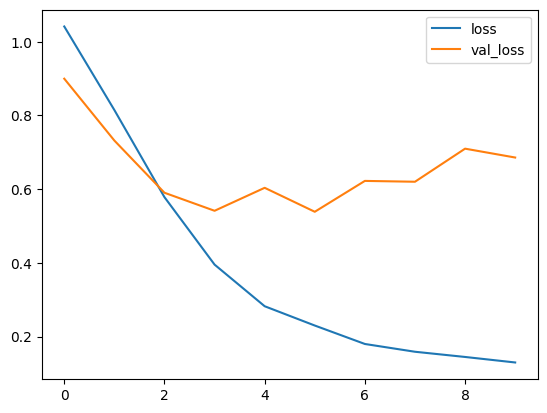

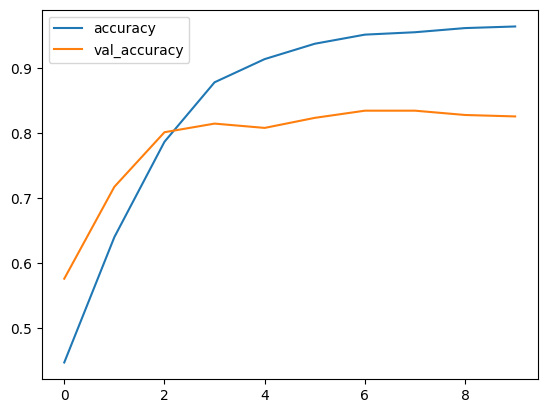

In [31]:
history = pd.DataFrame(history.history)

history[["loss", "val_loss"]].plot()
history[["accuracy", "val_accuracy"]].plot()
plt.show()

In [32]:
from sklearn.metrics import classification_report
y_pred = model.predict(test_ds)
print(classification_report(y_test, np.argmax(y_pred, axis=1)))

36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 628ms/step
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       361
           1       0.80      0.75      0.78       408
           2       0.78      0.81      0.80       362

    accuracy                           0.78      1131
   macro avg       0.78      0.78      0.78      1131
weighted avg       0.78      0.78      0.78      1131



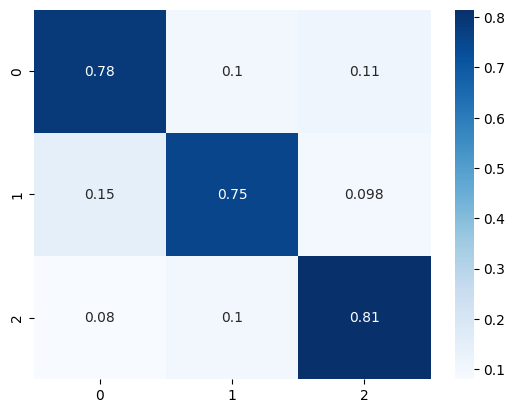

In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, cmap="Blues")
plt.show()

In [22]:
test_texts = [
    # -------------------
    # Positive (Class 2)
    # -------------------
    "The company reported strong quarterly earnings driven by increased demand and improved operational efficiency.",
    "The firm announced a major investment in renewable energy projects, boosting investor confidence.",
    "Revenue growth exceeded expectations, supported by expansion into new markets.",
    "The company's sustainability initiatives have significantly improved its ESG rating.",
    "The acquisition is expected to strengthen the company's market position and increase profitability.",
    "The company's improved governance structure strengthened investor confidence.",

    # -------------------
    # Negative (Class 0)
    # -------------------
    "The company reported significant losses due to declining sales and rising operational costs.",
    "The firm faces regulatory scrutiny over environmental violations.",
    "Revenue dropped sharply following weaker demand and supply chain disruptions.",
    "The company downgraded its earnings forecast due to market uncertainty.",
    "Investors expressed concerns about governance issues and declining margins.",
    "The firm's carbon emissions increased, raising concerns among stakeholders.",

    # -------------------
    # Neutral (Class 1)
    # -------------------
    "The company announced its quarterly financial results for the fiscal year.",
    "The board approved the annual sustainability report.",
    "The firm expanded its operations into Southeast Asia.",
    "The company held its annual shareholder meeting yesterday.",
    "The organization published its ESG disclosure report for 2024.",
    "The company updated its ESG reporting framework.",

    # -------------------
    # Hard / Edge Cases
    # -------------------
    "The company reported stable earnings despite market volatility.",
    "The firm maintained its previous ESG score.",
    "The company expects moderate growth in the coming quarters."
]

In [34]:
test_tensor = tf.constant(test_texts, dtype=tf.string)

pred = model.predict(test_tensor)
pred_classes = np.argmax(pred, axis=1)
pred_labels = le.inverse_transform(pred_classes)
reverse_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

for text, label in zip(test_texts, pred_labels):
    print(f"{reverse_map[label]} -> {text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
positive -> The company reported strong quarterly earnings driven by increased demand and improved operational efficiency.
positive -> The firm announced a major investment in renewable energy projects, boosting investor confidence.
positive -> Revenue growth exceeded expectations, supported by expansion into new markets.
positive -> The company's sustainability initiatives have significantly improved its ESG rating.
positive -> The acquisition is expected to strengthen the company's market position and increase profitability.
positive -> The company's improved governance structure strengthened investor confidence.
negative -> The company reported significant losses due to declining sales and rising operational costs.
negative -> The firm faces regulatory scrutiny over environmental violations.
negative -> Revenue dropped sharply following weaker demand and supply chain disruptions.
negative -> The company downgraded its earnings forecast due to m